# Topic 3 — Dimensionality Reduction
**Covers:** Curse of dimensionality · Projection vs. selection · PCA vs. SVD · Linear vs.
non-linear reduction

**The story:** InstaMetrics wants a single, clean **"Post Performance Dashboard"** for
creators — but you're tracking SIX different engagement numbers per post (likes, comments,
shares, saves, views, engagement rate). Showing a creator six overlapping charts is confusing.
Your job: compress these into the smallest number of genuinely distinct "scores" that still
capture what's really going on.

**Dataset:** `data/raw/instagram_posts.csv` — focusing on the block of engagement metrics,
which are strongly (but not perfectly) correlated with each other, by construction.

---
## Explanation

Imagine you have SIX different rulers measuring how much a kid likes a toy: how big their
smile is, how loud they laugh, how long they play with it, how many times they ask for it
again, how fast they run to grab it, and how sad they get when it's taken away.

That's a LOT of rulers for one simple idea: "does the kid like this toy?" Most of these
numbers move together — a kid who smiles big usually also laughs loud and plays longer.

- **Curse of dimensionality** = the more separate rulers (measurements) you track for every
  toy, the harder it gets to compare toys fairly — everything starts looking "kind of far
  apart from everything else," and patterns get buried under the sheer number of rulers.
- **Projection vs. selection** = **selection** means picking your 2 FAVORITE rulers and
  throwing the rest away. **Projection** means inventing ONE BRAND NEW ruler that's a clever
  blend of all six — like "excitement score" — that captures most of what all six original
  rulers were telling you, without throwing any of their information away completely.
- **PCA vs. SVD** = two different tools that both find the best new "excitement score" ruler —
  they're closely related recipes that arrive at (almost) the same answer.
- **Linear vs. non-linear reduction** = PCA only knows how to draw STRAIGHT blends of your
  rulers (like "smile + laugh, in equal parts"). Some patterns are naturally CURVY, and need a
  fancier, bendier tool to compress properly.

## 1. WHY — Why compress six engagement numbers into fewer?

Six numbers per post isn't just visually cluttered — it's genuinely harder to model and
analyze:
- Highly correlated inputs can destabilize some models (multicollinearity).
- More dimensions mean more room for spurious patterns and overfitting on limited data.
- A human dashboard with 6 charts per post is not a *dashboard*, it's a *spreadsheet*.

We want the smallest number of **new, genuinely different** scores that still capture most of
what these six numbers are telling us.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/instagram_posts.csv")
engagement_cols = ["likes_count", "comments_count", "shares_count", "saves_count",
                    "views_count", "engagement_rate"]
X_engagement = df[engagement_cols].copy()
X_engagement.describe().round(2)

,likes_count,comments_count,shares_count,saves_count,views_count,engagement_rate
count,1400.00,1400.00,1400.00,1400.00,1400.00,1400.00
mean,487.23,74.65,53.83,60.35,74405.91,0.09
std,308.06,49.13,36.43,40.17,165798.11,0.08
min,42.00,7.00,4.00,3.00,365.00,0.00
25%,234.00,35.00,25.00,28.00,7159.00,0.01
50%,427.50,65.00,47.00,52.00,22118.50,0.09
75%,664.50,101.00,72.00,81.00,72296.25,0.15
max,2089.00,296.00,258.00,233.00,2376782.00,0.29


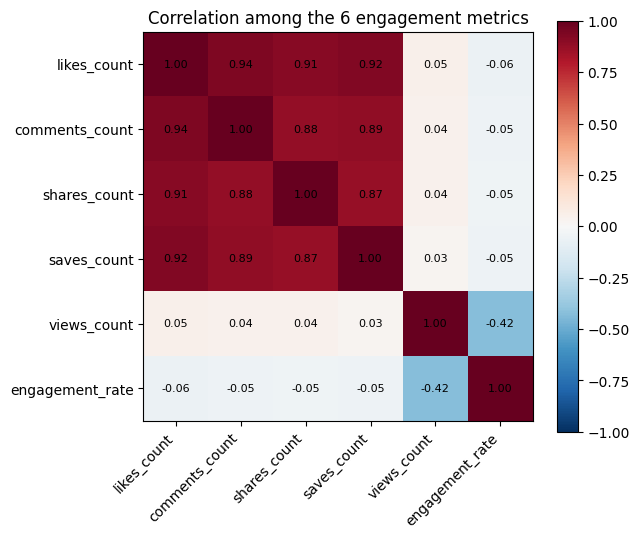

In [2]:
corr = X_engagement.corr()
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(engagement_cols))); ax.set_xticklabels(engagement_cols, rotation=45, ha="right")
ax.set_yticks(range(len(engagement_cols))); ax.set_yticklabels(engagement_cols)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im)
plt.title("Correlation among the 6 engagement metrics")
plt.tight_layout()
plt.show()

**What to notice:** `likes_count`, `comments_count`, `shares_count`, and `saves_count` are all
STRONGLY correlated with each other (they're all driven by the same underlying "how good was
this post" factor) — but `views_count` and `engagement_rate` behave more independently (views
measures *reach*, which is a genuinely different concept from *engagement*). This hints we'll
likely need **more than one** new compressed dimension to capture the real structure here — not
everything collapses into a single "excitement score."

## 2. Curse of dimensionality — a concrete demonstration

**Manual intuition.** Imagine placing 100 posts randomly in a space with more and more
dimensions. In low dimensions, some posts are clearly "close" (similar) and others clearly
"far" (different). In high dimensions, that distinction breaks down — everything becomes
roughly equidistant from everything else, and "similar posts" stops being meaningful.

In [3]:
from sklearn.metrics import pairwise_distances

rng = np.random.default_rng(0)
n_points = 150

print(f"{'Dimensions':<12}{'Avg nearest dist':<18}{'Avg farthest dist':<18}{'Farthest/Nearest ratio'}")
for n_dims in [1, 2, 6, 20, 100, 500]:
    points = rng.uniform(0, 1, size=(n_points, n_dims))
    dists = pairwise_distances(points)
    np.fill_diagonal(dists, np.nan)
    nearest = np.nanmin(dists, axis=1).mean()
    farthest = np.nanmax(dists, axis=1).mean()
    print(f"{n_dims:<12}{nearest:<18.3f}{farthest:<18.3f}{farthest/nearest:<10.3f}")

Dimensions  Avg nearest dist  Avg farthest dist Farthest/Nearest ratio
1           0.003             0.759             235.206   
2           0.041             0.998             24.153    
6           0.340             1.502             4.418     
20          1.180             2.380             2.018     
100         3.455             4.658             1.348     
500         8.524             9.704             1.138     


In just 1-2 dimensions, the farthest point is many times more distant than the nearest —
"near" and "far" mean something. By hundreds of dimensions, that ratio collapses toward 1 —
every point looks roughly equally (un)similar to every other point. Our 6 engagement metrics
alone are nowhere near "hundreds of dimensions," but real production feature sets (dozens to
hundreds of engineered columns) hit this problem for real — which is exactly why dimensionality
reduction matters at scale, not just as a visualization trick.

## 3. Projection vs. Selection — WHY / WHAT / HOW

**Selection** (Unit 2, Topics 5-6): pick a SUBSET of the original columns, drop the rest
entirely. **Projection**: create brand NEW columns, each a weighted COMBINATION of ALL the
original columns, chosen so the new columns capture as much of the original information as
possible in far fewer dimensions.

**Manual illustration.** Selection might keep `likes_count` and `views_count`, discarding
`comments_count`, `shares_count`, `saves_count`, and `engagement_rate` completely — losing
whatever unique information those four held. Projection instead builds something like:
```
new_score_1 = 0.42*likes + 0.39*comments + 0.35*shares + 0.37*saves - 0.08*views + 0.02*rate
```
blending a little information from EVERY original column into one new axis, rather than
throwing four of them away outright.

In [4]:
from sklearn.feature_selection import SelectKBest, f_regression

# Illustrative SELECTION: keep just the 2 columns most correlated with likes_count as a stand-in target
selector = SelectKBest(f_regression, k=2)
selector.fit(X_engagement.drop(columns=["likes_count"]), X_engagement["likes_count"])
selected_cols = X_engagement.drop(columns=["likes_count"]).columns[selector.get_support()]
print("SELECTION would keep only:", list(selected_cols), "-- discarding the rest entirely")

SELECTION would keep only: ['comments_count', 'saves_count'] -- discarding the rest entirely


## 4. PCA vs. SVD — WHY / WHAT / HOW

**Why they're closely related:** Principal Component Analysis (PCA) finds new axes (principal
components) that capture the maximum possible variance in the data, one axis at a time, each
new axis orthogonal (uncorrelated) to the ones before it. **Singular Value Decomposition
(SVD)** is the underlying linear-algebra machinery that actually computes this — in fact,
scikit-learn's `PCA` uses SVD internally. Run both, and (after centering the data, which PCA
does automatically) they land on the same projected result.

In [5]:
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X_engagement)

pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_scaled)

# TruncatedSVD works directly (no auto-centering) -- so we center manually to make it equivalent to PCA
X_centered = X_scaled - X_scaled.mean(axis=0)
svd = TruncatedSVD(n_components=2, random_state=42)
svd_result = svd.fit_transform(X_centered)

print("PCA component 1, first 5 rows: ", pca_result[:5, 0].round(3))
print("SVD component 1, first 5 rows: ", svd_result[:5, 0].round(3))
print("\n(Signs can flip between implementations -- magnitude and relative pattern should match)")

PCA component 1, first 5 rows:  [-1.447  2.838  0.482  5.389  0.498]
SVD component 1, first 5 rows:  [-1.447  2.838  0.482  5.389  0.498]

(Signs can flip between implementations -- magnitude and relative pattern should match)


In [6]:
correlation_between_methods = np.corrcoef(pca_result[:, 0], svd_result[:, 0])[0, 1]
print(f"Correlation between PCA's and SVD's first component: {abs(correlation_between_methods):.4f}")
print("(Should be extremely close to 1.0 in absolute value -- confirming they find the same axis)")

Correlation between PCA's and SVD's first component: 1.0000
(Should be extremely close to 1.0 in absolute value -- confirming they find the same axis)


**When to reach for which:** `PCA` is the standard choice for dense data (our case). `SVD`
(specifically `TruncatedSVD`) is preferred for very high-dimensional **sparse** data — exactly
the kind Topic 5 (Text Features) produces from Bag-of-Words/TF-IDF, where centering the data
(as PCA requires) would destroy the sparsity and blow up memory usage.

## 5. Linear vs. non-linear reduction — WHY / WHAT / HOW

**Why it matters:** PCA can only combine features in straight-line (linear) blends. If the
TRUE underlying structure is curved, PCA will still run — but it may badly misrepresent the
real relationships. Let's build a small synthetic example where the true structure is a curve
(a classic "S-curve" manifold) to see PCA's linear limitation directly, then compress it with a
non-linear method instead.

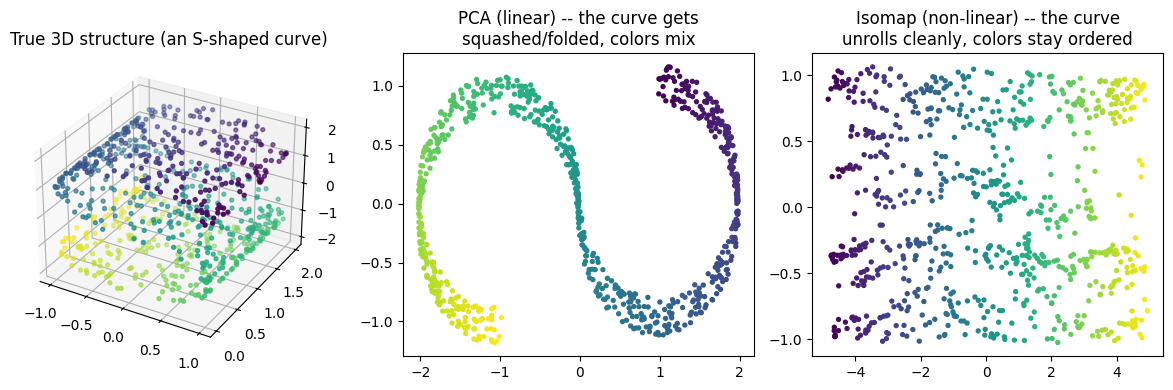

In [7]:
from sklearn.datasets import make_s_curve
from sklearn.manifold import Isomap

X_curve, color = make_s_curve(n_samples=800, random_state=42)

fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(131, projection="3d")
ax1.scatter(X_curve[:, 0], X_curve[:, 1], X_curve[:, 2], c=color, cmap="viridis", s=8)
ax1.set_title("True 3D structure (an S-shaped curve)")

pca_curve = PCA(n_components=2).fit_transform(X_curve)
ax2 = fig.add_subplot(132)
ax2.scatter(pca_curve[:, 0], pca_curve[:, 1], c=color, cmap="viridis", s=8)
ax2.set_title("PCA (linear) -- the curve gets\nsquashed/folded, colors mix")

isomap_curve = Isomap(n_neighbors=10, n_components=2).fit_transform(X_curve)
ax3 = fig.add_subplot(133)
ax3.scatter(isomap_curve[:, 0], isomap_curve[:, 1], c=color, cmap="viridis", s=8)
ax3.set_title("Isomap (non-linear) -- the curve\nunrolls cleanly, colors stay ordered")

plt.tight_layout()
plt.show()

**How to read this:** the true data lives on a curved 2D surface bent through 3D space (like
a rolled-up sheet of paper). PCA can only slice straight through it — points that were actually
far apart along the curve can end up looking close together after a linear projection (the
colors visibly mix in the PCA panel). **Isomap** (a non-linear manifold-learning method) instead
"unrolls" the curve, preserving the true along-the-surface distances — the color gradient stays
clean and ordered. For OUR engagement metrics (Section 1), the strong LINEAR correlations we
saw in the heatmap suggest PCA is actually a good fit here — but this synthetic example shows
exactly when it wouldn't be, and why non-linear methods (Isomap, t-SNE, UMAP, Kernel PCA) exist
at all.

## 6. Applying PCA to our real engagement metrics

In [8]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

print("Explained variance ratio per component:")
for i, ratio in enumerate(pca_full.explained_variance_ratio_, 1):
    print(f"  PC{i}: {ratio:.3f}  (cumulative: {pca_full.explained_variance_ratio_[:i].sum():.3f})")

Explained variance ratio per component:
  PC1: 0.619  (cumulative: 0.619)
  PC2: 0.236  (cumulative: 0.854)
  PC3: 0.096  (cumulative: 0.951)
  PC4: 0.022  (cumulative: 0.973)
  PC5: 0.018  (cumulative: 0.991)
  PC6: 0.009  (cumulative: 1.000)


Consistent with the correlation heatmap in Section 1: the first TWO components together
capture the large majority of the variance (roughly matching our earlier observation that there
are really two distinct underlying ideas here — "engagement" and "reach" — not just one). We'll
go much deeper on choosing the right number of components, reading the loadings, and the
resulting loss of interpretability in the next notebook, **PCA Practical**.

## 7. Recap

- **Curse of dimensionality**: more dimensions make "near" and "far" stop being meaningful,
  hurting distance-based methods and increasing overfitting risk.
- **Selection** keeps a subset of original columns as-is; **projection** builds new columns
  that blend information from ALL original columns.
- **PCA and SVD** are two closely related routes to the same linear projection; PCA suits
  dense data, SVD (`TruncatedSVD`) suits large sparse data (previewing Topic 5).
- **Linear (PCA) vs. non-linear (Isomap/t-SNE/UMAP) reduction**: PCA can only find
  straight-line blends; genuinely curved structure needs a non-linear method to compress
  faithfully.

**ELI5 recap:** picking your 2 favorite rulers and tossing the rest (selection) vs. inventing
one clever "excitement score" ruler that blends all six (projection); PCA and SVD are two
recipes that land on the same blended ruler; and if the real pattern is curvy instead of
straight, you need a bendier tool than PCA to compress it properly.